In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from math import sqrt
import ROOT
import ctypes
import sys
try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style") 
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

from matplotlib.ticker import ScalarFormatter


Welcome to JupyROOT 6.26/04


In [2]:
from math import sqrt

# Error-weighted combination function
def combine_error_weighted(x, y, x_err, y_err):
    central_value = (x / x_err**2 + y / y_err**2) / (1 / x_err**2 + 1 / y_err**2)
    error = 1 / sqrt(1 / x_err**2 + 1 / y_err**2)
    return central_value, error

In [3]:
def combine_x_plus_y_divided_by_2(x, y, x_err, y_err):
    central_value = (x+y)/2
    error = sqrt(x_err**2 +  y_err**2)/2
    return central_value, error

In [4]:
def correct_Acp_stats( Araw, Araw_err, Aref, Aref_err, Aref_pdg, Aref_K_mix):
    final_Acp = Araw - Aref + Aref_pdg + Aref_K_mix
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

In [5]:
def correct_Acp_stats_no_Kmix( Araw, Araw_err, Aref, Aref_err, Aref_pdg):
    final_Acp = Araw - Aref + Aref_pdg 
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

In [6]:
def delta_Acp_sys_unc(A_original, A_original_error, A, A_error):
    delta_Acp = A - A_original
    if A_original_error > A_error:
        delta_Acp_error = sqrt(A_original_error**2 - A_error**2)
    elif A_original_error < A_error:
        delta_Acp_error = sqrt(A_error**2 - A_original_error**2)
    else: 
        print("Error: unable to proceed.")
        sys.exit()

    print(f"delta_Acp: {delta_Acp}, delta_Acp_error: {delta_Acp_error}")
    return delta_Acp, delta_Acp_error

# MC15 full

## Acp(D+ -> eta pi+)

### eta -> gg

In [93]:
Aref_gg_cms_plus = -0.004595100565121147
Aref_gg_cms_plus_error = 0.002567813503592006
Aref_gg_cms_minus = 0.009236304439507476
Aref_gg_cms_minus_error =0.002798125624981967
Aref_gg_orginal, Aref_gg_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg_orginal: {Aref_gg_orginal}, Aref_gg_stats_error_orginal: {Aref_gg_stats_error_orginal}")

Aref_gg_orginal: 0.0023206019371931645, Aref_gg_stats_error_orginal: 0.0018988926511529145


In [9]:
# (p,cos theata) weighted
Aref_gg_cms_plus = -0.00467405063414355
Aref_gg_cms_plus_error = 0.002568354184813555
Aref_gg_cms_minus = 0.009204909156115104
Aref_gg_cms_minus_error = 0.002799389964738844
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.002265429260985777, Aref_gg_stats_error: 0.0018995412204878476


In [34]:
# CB convolved by gauss
Aref_gg_cms_plus = -0.004575195599147645
Aref_gg_cms_plus_error = 0.002568252596350121
Aref_gg_cms_minus = 0.009236897629376059
Aref_gg_cms_minus_error = 0.002795105709571548
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.002330851015114207, Aref_gg_stats_error: 0.001897928958518904


In [52]:
# bkg: 1st poly
Aref_gg_cms_plus = -0.0045849667109446515
Aref_gg_cms_plus_error = 0.0025770994704244743
Aref_gg_cms_minus = 0.009231790460501954
Aref_gg_cms_minus_error = 0.0028059437268813255
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.0023234118747786515, Aref_gg_stats_error: 0.0019049121947537877


In [72]:
# bkg: 2nd poly
Aref_gg_cms_plus = -0.0045871573388222625
Aref_gg_cms_plus_error = 0.002573390151727124
Aref_gg_cms_minus = 0.009227849847886
Aref_gg_cms_minus_error = 0.002803989216384818
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.002320346254531869, Aref_gg_stats_error: 0.0019029380178166926


In [96]:
# Acp params intro. mean
float_var = "mean"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.00232578987408711, Aref_gg_stats_error: 0.0018988949231921058

  RooFitResult: minimized FCN value: -210583, estimated distance to minimum: 0.000862511
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.5852e-03 +/-  2.57e-03
               Acp_bkg   -1.8833e-02 +/-  9.13e-03
              Acp_mean   -2.1792e-07 +/-  7.00e-06
               N_total    1.6915e+05 +/-  6.28e+02
            Nbkg_total    2.2434e+04 +/-  4.97e+02
                 delta    6.1034e-01 +/-  2.11e-02
                 gamma    7.4574e-02 +/-  6.68e-03
             mean_plus    1.8702e+00 +/-  2.83e-05
                 sigma    1.5117e-03 +/-  1.13e-04
           sigma_gauss    3.0362e-03 +/-  6.00e-05
            x_bkg1_tau   -6.4320e+00 +/-  2.72e-01


  RooFitResult: minimized FCN value: -171430, estima

Error in <TList::Delete>: A list is accessing an object (0x5587b5043940) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5885540) already deleted (list name = TList)


In [98]:
# Acp params intro. delta
float_var = "delta"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.0026884547382486834, Aref_gg_stats_error: 0.002049717904770597

  RooFitResult: minimized FCN value: -210584, estimated distance to minimum: 0.000312636
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -3.9018e-03 +/-  2.77e-03
               Acp_bkg   -2.4134e-02 +/-  1.20e-02
             Acp_delta   -2.5969e-03 +/-  3.87e-03
               N_total    1.6915e+05 +/-  6.27e+02
            Nbkg_total    2.2449e+04 +/-  4.96e+02
            delta_plus    6.0940e-01 +/-  2.12e-02
                 gamma    7.4763e-02 +/-  6.69e-03
                  mean    1.8702e+00 +/-  2.51e-05
                 sigma    1.5150e-03 +/-  1.13e-04
           sigma_gauss    3.0346e-03 +/-  6.00e-05
            x_bkg1_tau   -6.4260e+00 +/-  2.71e-01


  RooFitResult: minimized FCN value: -171430, estim

Error in <TList::Delete>: A list is accessing an object (0x5587b5895680) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b58950b0) already deleted (list name = TList)


In [100]:
# Acp params intro. gamma
float_var = "gamma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.002310547007455631, Aref_gg_stats_error: 0.0018998618590081665

  RooFitResult: minimized FCN value: -210583, estimated distance to minimum: 0.000143605
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.6087e-03 +/-  2.57e-03
               Acp_bkg   -1.8774e-02 +/-  9.15e-03
             Acp_gamma    2.1661e-03 +/-  4.61e-02
               N_total    1.6915e+05 +/-  6.27e+02
            Nbkg_total    2.2444e+04 +/-  4.96e+02
                 delta    6.1060e-01 +/-  2.11e-02
            gamma_plus    7.4861e-02 +/-  7.52e-03
                  mean    1.8702e+00 +/-  2.51e-05
                 sigma    1.5132e-03 +/-  1.13e-04
           sigma_gauss    3.0352e-03 +/-  6.00e-05
            x_bkg1_tau   -6.4305e+00 +/-  2.72e-01


  RooFitResult: minimized FCN value: -171430, estim

Error in <TList::Delete>: A list is accessing an object (0x5587b58a1e60) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b58a26b0) already deleted (list name = TList)


In [102]:
# Acp params intro. sigma
float_var = "sigma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.0024188331380546537, Aref_gg_stats_error: 0.001959929461871104

  RooFitResult: minimized FCN value: -210583, estimated distance to minimum: 4.07841e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.2171e-03 +/-  2.65e-03
               Acp_bkg   -2.1724e-02 +/-  1.04e-02
             Acp_sigma    3.8784e-03 +/-  6.55e-03
               N_total    1.6915e+05 +/-  6.27e+02
            Nbkg_total    2.2443e+04 +/-  4.97e+02
                 delta    6.1056e-01 +/-  2.11e-02
                 gamma    7.4711e-02 +/-  6.69e-03
                  mean    1.8702e+00 +/-  2.51e-05
           sigma_gauss    3.0355e-03 +/-  6.00e-05
            sigma_plus    1.5188e-03 +/-  1.14e-04
            x_bkg1_tau   -6.4303e+00 +/-  2.72e-01


  RooFitResult: minimized FCN value: -171430, estim

Error in <TList::Delete>: A list is accessing an object (0x5587b58a3a10) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b58b50e0) already deleted (list name = TList)


In [104]:
# Acp params intro. sigma_gauss
float_var = "sigma_gauss"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.002248257067588888, Aref_gg_stats_error: 0.0019011122058255865

  RooFitResult: minimized FCN value: -210583, estimated distance to minimum: 0.00016594
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.6071e-03 +/-  2.57e-03
               Acp_bkg   -1.8757e-02 +/-  9.18e-03
       Acp_sigma_gauss   -8.8384e-05 +/-  5.02e-03
               N_total    1.6915e+05 +/-  6.27e+02
            Nbkg_total    2.2444e+04 +/-  4.96e+02
                 delta    6.1056e-01 +/-  2.11e-02
                 gamma    7.4781e-02 +/-  6.68e-03
                  mean    1.8702e+00 +/-  2.50e-05
                 sigma    1.5130e-03 +/-  1.13e-04
      sigma_gauss_plus    3.0350e-03 +/-  6.20e-05
            x_bkg1_tau   -6.4266e+00 +/-  2.71e-01


  RooFitResult: minimized FCN value: -171430, estima

Error in <TList::Delete>: A list is accessing an object (0x5587b58be040) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b56d0020) already deleted (list name = TList)


In [106]:
# Acp params intro. x_bkg1_tau
float_var = "x_bkg1_tau"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/gg/generic/fitresult/MC15rd_1ab_Kspip_gg_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.83_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.0023036727596980363, Aref_gg_stats_error: 0.0019060924637175638

  RooFitResult: minimized FCN value: -210583, estimated distance to minimum: 0.00497633
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.6091e-03 +/-  2.58e-03
               Acp_bkg   -1.8813e-02 +/-  9.32e-03
        Acp_x_bkg1_tau   -1.1646e-03 +/-  3.29e-02
               N_total    1.6919e+05 +/-  6.29e+02
            Nbkg_total    2.2404e+04 +/-  4.99e+02
                 delta    6.0851e-01 +/-  2.11e-02
                 gamma    7.4564e-02 +/-  6.68e-03
                  mean    1.8702e+00 +/-  2.50e-05
                 sigma    1.5019e-03 +/-  1.13e-04
           sigma_gauss    3.0410e-03 +/-  5.98e-05
       x_bkg1_tau_plus   -6.4359e+00 +/-  3.48e-01


  RooFitResult: minimized FCN value: -171430, estim

Error in <TList::Delete>: A list is accessing an object (0x5587b56ef360) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5804430) already deleted (list name = TList)


In [107]:
A_orginal = Aref_gg_orginal
A_original_error = Aref_gg_stats_error_orginal
A = Aref_gg
A_error = Aref_gg_stats_error


delta_Acp_sys_unc(A_orginal, A_original_error, A, A_error)

delta_Acp: -1.6929177495128133e-05, delta_Acp_error: 0.00016551489249716503


(-1.6929177495128133e-05, 0.00016551489249716503)

## Acp(Ds+ -> eta pi+)

### eta -> gg

In [8]:
Aref_gg_cms_plus = -0.004595100565121147
Aref_gg_cms_plus_error = 0.002567813503592006
Aref_gg_cms_minus = 0.009236304439507476
Aref_gg_cms_minus_error = 0.002798125624981967
Aref_gg_orginal, Aref_gg_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg_orginal: {Aref_gg_orginal}, Aref_gg_stats_error_orginal: {Aref_gg_stats_error_orginal}")

Aref_gg_orginal: 0.0023206019371931645, Aref_gg_stats_error_orginal: 0.0018988926511529145


In [9]:
# (p,cos theata) weighted
Aref_gg_cms_plus = -0.004632269098001256
Aref_gg_cms_plus_error = 0.002569743599286191
Aref_gg_cms_minus = 0.008950349781486764
Aref_gg_cms_minus_error = 0.0028012351914173867
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.002159040341742754, Aref_gg_stats_error: 0.001900690714168638


In [30]:
# # (p,cos theata) weighted
# Aref_gg_cms_plus = -0.004534538525406697
# Aref_gg_cms_plus_error = 0.002558749749765302
# Aref_gg_cms_minus = 0.008978430325332992
# Aref_gg_cms_minus_error = 0.0028069319103257197
# Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

# print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.0022219458999631478, Aref_gg_stats_error: 0.0018990831360902022


In [10]:
A_orginal = Aref_gg_orginal
A_original_error = Aref_gg_stats_error_orginal
A = Aref_gg
A_error = Aref_gg_stats_error


delta_Acp_sys_unc(A_orginal, A_original_error, A, A_error)

delta_Acp: -0.0001615615954504105, delta_Acp_error: 8.265524982929549e-05


(-0.0001615615954504105, 8.265524982929549e-05)

## Acp(D+ -> eta pi+)

### eta -> pipipi

In [133]:
Aref_pipipi_cms_plus = -0.005480496235349852
Aref_pipipi_cms_plus_error = 0.002307686671685197
Aref_pipipi_cms_minus = 0.009362030023348837
Aref_pipipi_cms_minus_error = 0.0025262790166142588
Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi_orginal: {Aref_pipipi_orginal}, Aref_pipipi_stats_error_orginal: {Aref_pipipi_stats_error_orginal}")

Aref_pipipi_orginal: 0.0019407668939994925, Aref_pipipi_stats_error_orginal: 0.0017108114627610933


In [16]:
# (p,cos theata) weighted
Aref_pipipi_cms_plus = -0.005135516381651991
Aref_pipipi_cms_plus_error = 0.002308699081135743
Aref_pipipi_cms_minus = 0.009042492558956568
Aref_pipipi_cms_minus_error = 0.0025303473867870786
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

Aref_pipipi: 0.0019534880886522884, Aref_pipipi_stats_error: 0.001712655054663462


In [36]:
# (p,cos theata) weighted
Aref_pipipi_cms_plus = -0.005139119272541376
Aref_pipipi_cms_plus_error = 0.0023013259430333987
Aref_pipipi_cms_minus = 0.00902285103732507
Aref_pipipi_cms_minus_error = 0.002531862103362395
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

Aref_pipipi: 0.0019418658823918472, Aref_pipipi_stats_error: 0.0017107327966781672


In [37]:
# CB convolved gauss
Aref_pipipi_cms_plus = -0.0055250034742396915
Aref_pipipi_cms_plus_error = 0.0023064882753429314
Aref_pipipi_cms_minus = 0.009272651118394254
Aref_pipipi_cms_minus_error = 0.0025231330510839013
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

Aref_pipipi: 0.0018738238220772814, Aref_pipipi_stats_error: 0.0017092460734024204


In [59]:
# bkg: 1st poly
Aref_pipipi_cms_plus = -0.0054782387175712184
Aref_pipipi_cms_plus_error = 0.0023136982106787595
Aref_pipipi_cms_minus = 0.009333383309471404
Aref_pipipi_cms_minus_error = 0.0025301307561784343
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

Aref_pipipi: 0.0019275722959500928, Aref_pipipi_stats_error: 0.001714260850443869


In [121]:
# Acp params intro. mean
float_var = "mean"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_mean_plus: -1.4220522545076338e-06 pm 6.361527016951186e-06
A_float_var_mean_minus: -4.897027073324774e-06 pm 6.583522405215875e-06
Aref_pipipi: 0.001937809295555949, Aref_pipipi_stats_error: 0.0017069730693847198

  RooFitResult: minimized FCN value: -253268, estimated distance to minimum: 0.000422158
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -5.4986e-03 +/-  2.31e-03
               Acp_bkg   -1.6010e-02 +/-  6.17e-03
              Acp_mean   -1.4221e-06 +/-  6.36e-06
               N_total    2.1675e+05 +/-  7.99e+02
            Nbkg_total    4.5622e+04 +/-  6.83e+02
                 delta    5.9976e-01 +/-  2.02e-02
                 gamma    6.6931e-02 +/-  6.31e-03
             mean_plus    1.8701e+00 +/-  2.61e-05
                 sigma    1.5241e-03 +/-  1.08e-04
   

Error in <TList::Delete>: A list is accessing an object (0x5587b56e8a20) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5859600) already deleted (list name = TList)


In [123]:
# Acp params intro. delta
float_var = "delta"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_delta_plus: -0.002372313826692447 pm 0.003808153811070767
A_float_var_delta_minus: -0.003164900256058562 pm 0.005504498518514598
Aref_pipipi: 0.002788620872396777, Aref_pipipi_stats_error: 0.001981623318170763

  RooFitResult: minimized FCN value: -253268, estimated distance to minimum: 0.000859794
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.7342e-03 +/-  2.58e-03
               Acp_bkg   -1.9545e-02 +/-  8.28e-03
             Acp_delta   -2.3723e-03 +/-  3.81e-03
               N_total    2.1675e+05 +/-  8.16e+02
            Nbkg_total    4.5624e+04 +/-  7.02e+02
            delta_plus    5.9833e-01 +/-  2.13e-02
                 gamma    6.6983e-02 +/-  6.31e-03
                  mean    1.8701e+00 +/-  2.33e-05
                 sigma    1.5239e-03 +/-  1.13e-04
       

Error in <TList::Delete>: A list is accessing an object (0x5587b59a7ac0) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b59b2060) already deleted (list name = TList)


In [125]:
# Acp params intro. gamma
float_var = "gamma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_gamma_plus: -0.00300880023874495 pm 0.047331946269569276
A_float_var_gamma_minus: 0.047919055792436 pm 0.050750041418028954
Aref_pipipi: 0.001982138701936835, Aref_pipipi_stats_error: 0.0017080506124389208

  RooFitResult: minimized FCN value: -253268, estimated distance to minimum: 0.000361872
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -5.4785e-03 +/-  2.31e-03
               Acp_bkg   -1.6096e-02 +/-  6.17e-03
             Acp_gamma   -3.0088e-03 +/-  4.73e-02
               N_total    2.1675e+05 +/-  7.99e+02
            Nbkg_total    4.5622e+04 +/-  6.83e+02
                 delta    5.9984e-01 +/-  2.02e-02
            gamma_plus    6.6901e-02 +/-  7.09e-03
                  mean    1.8701e+00 +/-  2.33e-05
                 sigma    1.5245e-03 +/-  1.08e-04
           

Error in <TList::Delete>: A list is accessing an object (0x5587b59e1430) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b59ed030) already deleted (list name = TList)


In [127]:
# Acp params intro. sigma
float_var = "sigma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_sigma_plus: 0.0018578491124288808 pm 0.006151993943453134
A_float_var_sigma_minus: 0.004677365653915092 pm 0.010381043735621029
Aref_pipipi: 0.002274832271689789, Aref_pipipi_stats_error: 0.0018167102414573305

  RooFitResult: minimized FCN value: -253268, estimated distance to minimum: 4.77929e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -5.2535e-03 +/-  2.42e-03
               Acp_bkg   -1.7131e-02 +/-  7.07e-03
             Acp_sigma    1.8578e-03 +/-  6.15e-03
               N_total    2.1676e+05 +/-  8.05e+02
            Nbkg_total    4.5614e+04 +/-  6.90e+02
                 delta    5.9956e-01 +/-  2.05e-02
                 gamma    6.7007e-02 +/-  6.31e-03
                  mean    1.8701e+00 +/-  2.33e-05
           sigma_gauss    3.0386e-03 +/-  5.78e-05
       

Error in <TList::Delete>: A list is accessing an object (0x5587b5a0f170) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b59e4920) already deleted (list name = TList)


In [134]:
# Acp params intro. sigma_gauss
float_var = "sigma_gauss"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_sigma_gauss_plus: -0.003243264782072424 pm 0.0046002595598884834
A_float_var_sigma_gauss_minus: -0.00021005946511633929 pm 0.003982316015398387
Aref_pipipi: 0.001887108106828329, Aref_pipipi_stats_error: 0.0017108046194197204

  RooFitResult: minimized FCN value: -253268, estimated distance to minimum: 0.00101997
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -5.5973e-03 +/-  2.31e-03
               Acp_bkg   -1.5545e-02 +/-  6.21e-03
       Acp_sigma_gauss   -3.2433e-03 +/-  4.60e-03
               N_total    2.1675e+05 +/-  8.02e+02
            Nbkg_total    4.5635e+04 +/-  6.87e+02
                 delta    5.9989e-01 +/-  2.03e-02
                 gamma    6.7147e-02 +/-  6.31e-03
                  mean    1.8701e+00 +/-  2.33e-05
                 sigma    1.5245e-03 +/-  1

Error in <TList::Delete>: A list is accessing an object (0x5587b5a18420) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5a1c1b0) already deleted (list name = TList)


In [129]:
# Acp params intro. x_bkg1_tau
float_var = "x_bkg1_tau"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_plus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/Kspip/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_fit_opt_loose_v7_fitv1_train_Dp_CMS_p_Dp_CMS_minus_0.74_new_Ds_correct_float_var_{float_var}.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_x_bkg1_tau_plus: -0.014135441438062536 pm 0.029453367491816138
A_float_var_x_bkg1_tau_minus: 0.0018000542663821775 pm 0.04024819625025727
Aref_pipipi: 0.0019132349531600528, Aref_pipipi_stats_error: 0.0017127994472498893

  RooFitResult: minimized FCN value: -253268, estimated distance to minimum: 2.63766e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -5.5699e-03 +/-  2.32e-03
               Acp_bkg   -1.5660e-02 +/-  6.23e-03
        Acp_x_bkg1_tau   -1.4135e-02 +/-  2.95e-02
               N_total    2.1676e+05 +/-  8.05e+02
            Nbkg_total    4.5620e+04 +/-  6.90e+02
                 delta    5.9966e-01 +/-  2.06e-02
                 gamma    6.7053e-02 +/-  6.31e-03
                  mean    1.8701e+00 +/-  2.33e-05
                 sigma    1.5235e-03 +/-  1.10e

Error in <TList::Delete>: A list is accessing an object (0x5587b5a0ac10) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5a1c990) already deleted (list name = TList)


In [135]:
A_orginal = Aref_pipipi_orginal
A_original_error = Aref_pipipi_stats_error_orginal
A = Aref_pipipi
A_error = Aref_pipipi_stats_error


delta_Acp_sys_unc(A_orginal, A_original_error, A, A_error)

delta_Acp: -5.3658787171163586e-05, delta_Acp_error: 4.838934479572891e-06


(-5.3658787171163586e-05, 4.838934479572891e-06)

## Acp(Ds+ -> eta pi+)

### eta -> pipipi

In [13]:
Aref_pipipi_cms_plus = -0.005480496235349852
Aref_pipipi_cms_plus_error = 0.002307686671685197
Aref_pipipi_cms_minus = 0.009362030023348837
Aref_pipipi_cms_minus_error = 0.0025262790166142588
Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi_orginal: {Aref_pipipi_orginal}, Aref_pipipi_stats_error_orginal: {Aref_pipipi_stats_error_orginal}")

Aref_pipipi_orginal: 0.0019407668939994925, Aref_pipipi_stats_error_orginal: 0.0017108114627610933


In [14]:
# (p,cos theata) weighted
Aref_pipipi_cms_plus = -0.005090260118799728
Aref_pipipi_cms_plus_error =  0.002314183562562239
Aref_pipipi_cms_minus = 0.009142339693030166
Aref_pipipi_cms_minus_error = 0.002538666562680199
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

Aref_pipipi: 0.002026039787115219, Aref_pipipi_stats_error: 0.0017175763067258287


In [15]:
A_orginal = Aref_pipipi_orginal
A_original_error = Aref_pipipi_stats_error_orginal
A = Aref_pipipi
A_error = Aref_pipipi_stats_error


delta_Acp_sys_unc(A_orginal, A_original_error, A, A_error)

delta_Acp: 8.527289311572629e-05, delta_Acp_error: 0.0001522908674582488


(8.527289311572629e-05, 0.0001522908674582488)

## Acp(D+ -> eta K+)

### eta -> gg

In [164]:
Aref_gg_cms_plus = -0.003260298398113298
Aref_gg_cms_plus_error = 0.005711700573546128
Aref_gg_cms_minus = 0.018299066132560136
Aref_gg_cms_minus_error = 0.005933185641307683
Aref_gg_orginal, Aref_gg_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg_orginal: {Aref_gg_orginal}, Aref_gg_stats_error_orginal: {Aref_gg_stats_error_orginal}")

Aref_gg_orginal: 0.007519383867223419, Aref_gg_stats_error_orginal: 0.004117833632386902


In [43]:
# (p,cos theata) weighted
Aref_gg_cms_plus = -0.0028442817662855057
Aref_gg_cms_plus_error = 0.006094052498523269
Aref_gg_cms_minus = 0.019311692481853278
Aref_gg_cms_minus_error = 0.006359687885821263
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.008233705357783887, Aref_gg_stats_error: 0.004404063630893048


In [43]:
# CB convolved gauss
Aref_gg_cms_plus = -0.0034324665953960757
Aref_gg_cms_plus_error = 0.0057099348833768385
Aref_gg_cms_minus = 0.01831794063027303
Aref_gg_cms_minus_error = 0.005932561021656326
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.007442737017438477, Aref_gg_stats_error: 0.004116996376245661


In [63]:
# bkg: 1st poly
Aref_gg_cms_plus = -0.0033236818081318308
Aref_gg_cms_plus_error = 0.005709680868575097
Aref_gg_cms_minus = 0.018183915809745696
Aref_gg_cms_minus_error = 0.005931764259207222
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.007430117000806933, Aref_gg_stats_error: 0.004116621273805154


In [141]:
# Acp params intro. mean
float_var = "mean"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

A_float_var_mean_plus: 4.625700029321257e-07 pm 1.3417600902333694e-05
A_float_var_mean_minus: 8.54801837462879e-06 pm 1.266809732917477e-05
Aref_gg: 0.007502042612245232, Aref_gg_stats_error: 0.004117829652662944

  RooFitResult: minimized FCN value: -40397.5, estimated distance to minimum: 0.000428163
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -3.2438e-03 +/-  5.71e-03
               Acp_bkg   -5.1839e-02 +/-  2.42e-02
              Acp_mean    4.6257e-07 +/-  1.34e-05
               N_total    3.3679e+04 +/-  2.51e+02
            Nbkg_total    3.3889e+03 +/-  1.81e+02
                 delta    5.9823e-01 +/-  4.19e-02
                 gamma   -1.2508e-02 +/-  1.43e-02
             mean_plus    1.9687e+00 +/-  5.43e-05
                 sigma    1.2784e-03 +/-  2.04e-04
           sig

Error in <TList::Delete>: A list is accessing an object (0x5587b59682a0) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b4ba2140) already deleted (list name = TList)


In [143]:
# Acp params intro. delta
float_var = "delta"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

A_float_var_delta_plus: 0.00375556072605661 pm 0.008440407010055443
A_float_var_delta_minus: 0.0031495779187282373 pm 0.008059470214475044
Aref_gg: 0.006749265970642726, Aref_gg_stats_error: 0.004315645252981111

  RooFitResult: minimized FCN value: -40397.5, estimated distance to minimum: 4.07e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.2289e-03 +/-  6.09e-03
               Acp_bkg   -4.2244e-02 +/-  3.19e-02
             Acp_delta    3.7556e-03 +/-  8.44e-03
               N_total    3.3681e+04 +/-  2.51e+02
            Nbkg_total    3.3892e+03 +/-  1.81e+02
            delta_plus    6.0069e-01 +/-  4.23e-02
                 gamma   -1.2693e-02 +/-  1.43e-02
                  mean    1.9687e+00 +/-  4.75e-05
                 sigma    1.2793e-03 +/-  2.04e-04
           sigma_ga

Error in <TList::Delete>: A list is accessing an object (0x5587b574ea70) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5a777f0) already deleted (list name = TList)


In [156]:
# Acp params intro. gamma
float_var = "gamma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

A_float_var_gamma_plus: 0.1352560049847856 pm 0.5749699687929521
A_float_var_gamma_minus: -0.7781286499247712 pm 1.4075821920478573
Aref_gg: 0.007496258761809006, Aref_gg_stats_error: 0.004113688966467967

  RooFitResult: minimized FCN value: -42908, estimated distance to minimum: 0.000197511
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -3.2827e-03 +/-  5.71e-03
               Acp_bkg   -5.1567e-02 +/-  2.42e-02
             Acp_gamma    1.3526e-01 +/-  5.75e-01
               N_total    3.3677e+04 +/-  2.49e+02
            Nbkg_total    3.3933e+03 +/-  1.77e+02
                 delta    5.9928e-01 +/-  4.07e-02
            gamma_plus   -1.4463e-02 +/-  1.60e-02
                  mean    1.9687e+00 +/-  4.76e-05
                 sigma    1.2833e-03 +/-  1.98e-04
           sigma_gauss   

Error in <TList::Delete>: A list is accessing an object (0x5587b5ac9340) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5aee230) already deleted (list name = TList)


In [158]:
# Acp params intro. sigma
float_var = "sigma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

A_float_var_sigma_plus: -0.006072168956838475 pm 0.014890445695981908
A_float_var_sigma_minus: -0.007168138270256386 pm 0.01671736944299691
Aref_gg: 0.006992273798842533, Aref_gg_stats_error: 0.004197660975909644

  RooFitResult: minimized FCN value: -40397.5, estimated distance to minimum: 0.000589904
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -3.8241e-03 +/-  5.86e-03
               Acp_bkg   -4.6144e-02 +/-  2.74e-02
             Acp_sigma   -6.0722e-03 +/-  1.49e-02
               N_total    3.3681e+04 +/-  2.49e+02
            Nbkg_total    3.3883e+03 +/-  1.78e+02
                 delta    5.9815e-01 +/-  4.07e-02
                 gamma   -1.2939e-02 +/-  1.43e-02
                  mean    1.9687e+00 +/-  4.74e-05
           sigma_gauss    2.8255e-03 +/-  1.07e-04
            sig

Error in <TList::Delete>: A list is accessing an object (0x5587b5b00910) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5b17000) already deleted (list name = TList)


In [160]:
# Acp params intro. sigma_gauss
float_var = "sigma_gauss"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

A_float_var_sigma_gauss_plus: -0.002569488489949299 pm 0.010602720586646948
A_float_var_sigma_gauss_minus: -0.003229091235722571 pm 0.0091458100513602
Aref_gg: 0.007411281835174549, Aref_gg_stats_error: 0.004120087351773003

  RooFitResult: minimized FCN value: -40397.5, estimated distance to minimum: 0.000184718
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -3.3444e-03 +/-  5.72e-03
               Acp_bkg   -5.0934e-02 +/-  2.43e-02
       Acp_sigma_gauss   -2.5695e-03 +/-  1.06e-02
               N_total    3.3678e+04 +/-  2.49e+02
            Nbkg_total    3.3914e+03 +/-  1.78e+02
                 delta    5.9859e-01 +/-  4.08e-02
                 gamma   -1.2647e-02 +/-  1.43e-02
                  mean    1.9687e+00 +/-  4.75e-05
                 sigma    1.2794e-03 +/-  1.98e-04
    

Error in <TList::Delete>: A list is accessing an object (0x5587b5b0a020) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5b34ab0) already deleted (list name = TList)


In [165]:
# Acp params intro. x_bkg1_tau
float_var = "x_bkg1_tau"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_gg_cms_plus = Acp_plus.getVal()
Aref_gg_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/gg/generic/fitresult/MC15rd_Kspip_gg_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.91_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_gg_cms_minus = Acp_minus.getVal()
Aref_gg_cms_minus_error = Acp_minus.getError()

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")


Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

A_float_var_x_bkg1_tau_plus: -0.4970186472201892 pm 0.5719673379849937
A_float_var_x_bkg1_tau_minus: -0.8739217071084536 pm 0.309700961069977
Aref_gg: 0.007530663085187404, Aref_gg_stats_error: 0.004118348612960974

  RooFitResult: minimized FCN value: -39808.8, estimated distance to minimum: 0.000243485
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -3.1752e-03 +/-  5.71e-03
               Acp_bkg   -5.2726e-02 +/-  2.43e-02
        Acp_x_bkg1_tau   -4.9702e-01 +/-  5.72e-01
               N_total    3.3682e+04 +/-  2.51e+02
            Nbkg_total    3.3888e+03 +/-  1.81e+02
                 delta    5.9830e-01 +/-  4.20e-02
                 gamma   -1.2796e-02 +/-  1.43e-02
                  mean    1.9687e+00 +/-  4.75e-05
                 sigma    1.2790e-03 +/-  2.04e-04
           si

Error in <TList::Delete>: A list is accessing an object (0x5587b5b4e070) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5b37040) already deleted (list name = TList)


In [167]:
A_orginal = Aref_gg_orginal
A_original_error = Aref_gg_stats_error_orginal
A = Aref_gg
A_error = Aref_gg_stats_error


delta_Acp_sys_unc(A_orginal, A_original_error, A, A_error)

delta_Acp: 1.1279217963984858e-05, delta_Acp_error: 6.512659872024192e-05


(1.1279217963984858e-05, 6.512659872024192e-05)

## Acp(Ds+ -> eta K+)

### eta -> gg

In [17]:
Aref_gg_cms_plus = -0.003260298398113298
Aref_gg_cms_plus_error = 0.005711700573546128
Aref_gg_cms_minus = 0.018299066132560136
Aref_gg_cms_minus_error = 0.005933185641307683
Aref_gg_orginal, Aref_gg_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg_orginal: {Aref_gg_orginal}, Aref_gg_stats_error_orginal: {Aref_gg_stats_error_orginal}")

Aref_gg_orginal: 0.007519383867223419, Aref_gg_stats_error_orginal: 0.004117833632386902


In [18]:
# (p,cos theata) weighted
Aref_gg_cms_plus = -0.003482466786195134
Aref_gg_cms_plus_error = 0.00603270989396785
Aref_gg_cms_minus = 0.016764270012341456
Aref_gg_cms_minus_error = 0.006258236475987978
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

print(f"Aref_gg: {Aref_gg}, Aref_gg_stats_error: {Aref_gg_stats_error}")

Aref_gg: 0.006640901613073161, Aref_gg_stats_error: 0.004346237236224112


In [19]:
A_orginal = Aref_gg_orginal
A_original_error = Aref_gg_stats_error_orginal
A = Aref_gg
A_error = Aref_gg_stats_error


delta_Acp_sys_unc(A_orginal, A_original_error, A, A_error)

delta_Acp: -0.000878482254150258, delta_Acp_error: 0.0013904043618761764


(-0.000878482254150258, 0.0013904043618761764)

## Acp(D+ -> eta K+)

### eta -> pipipi

In [170]:
Aref_pipipi_cms_plus = -0.0044343150606245985
Aref_pipipi_cms_plus_error = 0.005512254980948661
Aref_pipipi_cms_minus = 0.016769204582985427
Aref_pipipi_cms_minus_error = 0.005806566788435947
Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi_orginal: {Aref_pipipi_orginal}, Aref_pipipi_stats_error_orginal: {Aref_pipipi_stats_error_orginal}")

Aref_pipipi_orginal: 0.006167444761180414, Aref_pipipi_stats_error_orginal: 0.004003160402843005


In [22]:
# (p,cos theata) weighted
Aref_pipipi_cms_plus = -0.003467350525971067
Aref_pipipi_cms_plus_error = 0.005875111993294166
Aref_pipipi_cms_minus = 0.01683807914924567
Aref_pipipi_cms_minus_error = 0.006157710697515206
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

Aref_pipipi: 0.006685364311637302, Aref_pipipi_stats_error: 0.004255418368622589


In [48]:
# CB convolved gauss
Aref_pipipi_cms_plus = -0.0044731131454479696
Aref_pipipi_cms_plus_error = 0.005510894721116811
Aref_pipipi_cms_minus = 0.016744517790072015
Aref_pipipi_cms_minus_error = 0.0058066351937087176
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

Aref_pipipi: 0.006135702322312022, Aref_pipipi_stats_error: 0.004002716980378759


In [67]:
# bkg: 1st poly
Aref_pipipi_cms_plus = -0.004429946261054706
Aref_pipipi_cms_plus_error = 0.005511888758310359
Aref_pipipi_cms_minus = 0.016716176816296696
Aref_pipipi_cms_minus_error = 0.005806665314744956
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

Aref_pipipi: 0.006143115277620995, Aref_pipipi_stats_error: 0.004003070064383406


In [171]:
# Acp params intro. mean
float_var = "mean"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_mean_plus: -6.883489651478877e-06 pm 1.3183853626655065e-05
A_float_var_mean_minus: 7.156224697108058e-06 pm 1.2485990758108353e-05
Aref_pipipi: 0.0061400652300908805, Aref_pipipi_stats_error: 0.004003140809323784

  RooFitResult: minimized FCN value: -47590.6, estimated distance to minimum: 2.80823e-05
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.4396e-03 +/-  5.51e-03
               Acp_bkg   -5.0771e-02 +/-  2.23e-02
              Acp_mean   -6.8835e-06 +/-  1.32e-05
               N_total    3.6447e+04 +/-  2.66e+02
            Nbkg_total    3.9910e+03 +/-  1.96e+02
                 delta    5.9447e-01 +/-  3.90e-02
                 gamma   -5.6653e-03 +/-  1.37e-02
             mean_plus    1.9687e+00 +/-  5.34e-05
                 sigma    1.3250e-03 +/-  1.94e-04
  

Error in <TList::Delete>: A list is accessing an object (0x5587b5b2f360) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5b597d0) already deleted (list name = TList)


In [173]:
# Acp params intro. delta
float_var = "delta"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_delta_plus: -0.00010519820135842676 pm 0.008287713595632119
A_float_var_delta_minus: 0.0025436470103394945 pm 0.008321934731950793
Aref_pipipi: 0.005915996698825924, Aref_pipipi_stats_error: 0.004224440268452739

  RooFitResult: minimized FCN value: -47590.5, estimated distance to minimum: 0.000371627
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.3624e-03 +/-  5.93e-03
               Acp_bkg   -5.0897e-02 +/-  2.98e-02
             Acp_delta   -1.0520e-04 +/-  8.29e-03
               N_total    3.6447e+04 +/-  2.66e+02
            Nbkg_total    3.9932e+03 +/-  1.96e+02
            delta_plus    5.9441e-01 +/-  3.92e-02
                 gamma   -5.5738e-03 +/-  1.37e-02
                  mean    1.9688e+00 +/-  4.66e-05
                 sigma    1.3247e-03 +/-  1.93e-04
    

Error in <TList::Delete>: A list is accessing an object (0x5587b5b768b0) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5b5b460) already deleted (list name = TList)


In [177]:
# Acp params intro. gamma
float_var = "gamma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_gamma_plus: 0.6879914094237577 pm 1.6768965578024324
A_float_var_gamma_minus: -0.41849800941446336 pm 0.3931137672364732
Aref_pipipi: 0.006121668037655568, Aref_pipipi_stats_error: 0.0040028951483830535

  RooFitResult: minimized FCN value: -49989, estimated distance to minimum: 0.000126252
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.4219e-03 +/-  5.51e-03
               Acp_bkg   -5.0752e-02 +/-  2.22e-02
             Acp_gamma    6.8799e-01 +/-  1.68e+00
               N_total    3.6441e+04 +/-  2.65e+02
            Nbkg_total    3.9965e+03 +/-  1.95e+02
                 delta    5.9534e-01 +/-  3.89e-02
            gamma_plus   -5.5454e-04 +/-  1.48e-02
                  mean    1.9688e+00 +/-  3.60e-05
                 sigma    1.3287e-03 +/-  1.93e-04
           sigm

Error in <TList::Delete>: A list is accessing an object (0x5587b5b85990) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5ba3a50) already deleted (list name = TList)


In [183]:
# Acp params intro. sigma
float_var = "sigma"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_sigma_plus: -0.0011118474947530881 pm 0.014307965866735398
A_float_var_sigma_minus: -0.007523685171403945 pm 0.018042833732395687
Aref_pipipi: 0.005919845603434147, Aref_pipipi_stats_error: 0.004092469220279052

  RooFitResult: minimized FCN value: -47590.5, estimated distance to minimum: 0.000745271
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.4781e-03 +/-  5.68e-03
               Acp_bkg   -5.0237e-02 +/-  2.55e-02
             Acp_sigma   -1.1118e-03 +/-  1.43e-02
               N_total    3.6448e+04 +/-  2.66e+02
            Nbkg_total    3.9895e+03 +/-  1.96e+02
                 delta    5.9421e-01 +/-  3.90e-02
                 gamma   -5.8475e-03 +/-  1.37e-02
                  mean    1.9687e+00 +/-  4.66e-05
           sigma_gauss    2.8308e-03 +/-  1.06e-04
     

Error in <TList::Delete>: A list is accessing an object (0x5587b5bb7590) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5bd9b80) already deleted (list name = TList)


In [181]:
# Acp params intro. sigma_gauss
float_var = "sigma_gauss"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_sigma_gauss_plus: -0.0031080740092127974 pm 0.010501645824517868
A_float_var_sigma_gauss_minus: -0.005268870283931464 pm 0.008540845905178621
Aref_pipipi: 0.006065133304277955, Aref_pipipi_stats_error: 0.004005656347946176

  RooFitResult: minimized FCN value: -47590.5, estimated distance to minimum: 0.000278342
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.5121e-03 +/-  5.52e-03
               Acp_bkg   -5.0037e-02 +/-  2.24e-02
       Acp_sigma_gauss   -3.1081e-03 +/-  1.05e-02
               N_total    3.6447e+04 +/-  2.66e+02
            Nbkg_total    3.9918e+03 +/-  1.96e+02
                 delta    5.9432e-01 +/-  3.90e-02
                 gamma   -5.5821e-03 +/-  1.37e-02
                  mean    1.9687e+00 +/-  4.66e-05
                 sigma    1.3238e-03 +/-  1.

Error in <TList::Delete>: A list is accessing an object (0x5587b5b78660) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5b757f0) already deleted (list name = TList)


In [191]:
# Acp params intro. x_bkg1_tau
float_var = "x_bkg1_tau"
f_plus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_plus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_plus = ROOT.gDirectory.Get("jykim")
f_plus.Close()
result_object_plus.Print()
fit_args_plus = result_object_plus.floatParsFinal()

Acp_plus = fit_args_plus.find("Acp")

Aref_pipipi_cms_plus = Acp_plus.getVal()
Aref_pipipi_cms_plus_error = Acp_plus.getError()

f_minus = ROOT.TFile.Open(f"/share/storage/jykim/plots/MC15rd/KsKp/pipipi/generic/fitresult/MC15rd_Kspip_pipipi_K_fit_opt_loose_v7_fitv1_Ds_train_Dp_CMS_p_Dp_CMS_minus_0.92_new_Ds_correct_float_var_{float_var}_wDpCMSp.root")
result_object_minus = ROOT.gDirectory.Get("jykim")
f_minus.Close()
result_object_minus.Print()
fit_args_minus = result_object_minus.floatParsFinal()

Acp_minus = fit_args_minus.find("Acp")

Aref_pipipi_cms_minus = Acp_minus.getVal()
Aref_pipipi_cms_minus_error = Acp_minus.getError()


Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

A_float_var_plus = fit_args_plus.find(f"Acp_{float_var}")
A_float_var_plus_val = A_float_var_plus.getVal()
A_float_var_plus_err = A_float_var_plus.getError()

A_float_var_minus = fit_args_minus.find(f"Acp_{float_var}")
A_float_var_minus_val = A_float_var_minus.getVal()
A_float_var_minus_err = A_float_var_minus.getError()


print(f"A_float_var_{float_var}_plus: {A_float_var_plus_val} pm {A_float_var_plus_err}")
print(f"A_float_var_{float_var}_minus: {A_float_var_minus_val} pm {A_float_var_minus_err}")

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

A_float_var_x_bkg1_tau_plus: -0.8278975292849269 pm 0.31966929381069276
A_float_var_x_bkg1_tau_minus: -0.8781388298834671 pm 0.3345009617097394
Aref_pipipi: 0.006224399481566649, Aref_pipipi_stats_error: 0.004003504089425472

  RooFitResult: minimized FCN value: -47590.9, estimated distance to minimum: 0.00120147
                covariance matrix quality: Full, accurate covariance matrix
                Status : MIGRAD=0 HESSE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
                   Acp   -4.3211e-03 +/-  5.51e-03
               Acp_bkg   -5.1821e-02 +/-  2.23e-02
        Acp_x_bkg1_tau   -8.2790e-01 +/-  3.20e-01
               N_total    3.6448e+04 +/-  2.66e+02
            Nbkg_total    3.9903e+03 +/-  1.95e+02
                 delta    5.9430e-01 +/-  3.92e-02
                 gamma   -5.2318e-03 +/-  1.31e-02
                  mean    1.9688e+00 +/-  4.54e-05
                 sigma    1.3242e-03 +/-  1.95e-04
    

Error in <TList::Delete>: A list is accessing an object (0x5587b5bd5c20) already deleted (list name = TList)
Error in <TList::Delete>: A list is accessing an object (0x5587b5c03710) already deleted (list name = TList)


In [192]:
A_orginal = Aref_pipipi_orginal
A_original_error = Aref_pipipi_stats_error_orginal
A = Aref_pipipi
A_error = Aref_pipipi_stats_error


delta_Acp_sys_unc(A_orginal, A_original_error, A, A_error)

delta_Acp: 5.6954720386234725e-05, delta_Acp_error: 5.245744138160151e-05


(5.6954720386234725e-05, 5.245744138160151e-05)

## Acp(Ds+ -> eta K+)

### eta -> pipipi

In [24]:
Aref_pipipi_cms_plus = -0.0044343150606245985
Aref_pipipi_cms_plus_error = 0.005512254980948661
Aref_pipipi_cms_minus = 0.016769204582985427
Aref_pipipi_cms_minus_error = 0.005806566788435947
Aref_pipipi_orginal, Aref_pipipi_stats_error_orginal = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi_orginal: {Aref_pipipi_orginal}, Aref_pipipi_stats_error_orginal: {Aref_pipipi_stats_error_orginal}")

Aref_pipipi_orginal: 0.006167444761180414, Aref_pipipi_stats_error_orginal: 0.004003160402843005


In [25]:
# Aref_pipipi_cms_plus = -0.0018457964078770525
# Aref_pipipi_cms_plus_error = 0.005556331303632802
# Aref_pipipi_cms_minus = 0.017480629031921165
# Aref_pipipi_cms_minus_error = 0.005853915315849488
# Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

# print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

In [26]:
# (p,cos theata) weighted separately
Aref_pipipi_cms_plus =  -0.003290657740997424
Aref_pipipi_cms_plus_error = 0.00563001581372469
Aref_pipipi_cms_minus = 0.017819111036400433
Aref_pipipi_cms_minus_error = 0.00593440283584992
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_pipipi_cms_plus,Aref_pipipi_cms_minus, Aref_pipipi_cms_plus_error,Aref_pipipi_cms_minus_error )

print(f"Aref_pipipi: {Aref_pipipi}, Aref_pipipi_stats_error: {Aref_pipipi_stats_error}")

Aref_pipipi: 0.007264226647701505, Aref_pipipi_stats_error: 0.00409005547275748


In [27]:
A_orginal = Aref_pipipi_orginal
A_original_error = Aref_pipipi_stats_error_orginal
A = Aref_pipipi
A_error = Aref_pipipi_stats_error


delta_Acp_sys_unc(A_orginal, A_original_error, A, A_error)

delta_Acp: 0.0010967818865210907, delta_Acp_error: 0.0008386063196418464


(0.0010967818865210907, 0.0008386063196418464)

Original Mean: 22.3
Bootstrap 95% Confidence Interval: (15.7, 29.557499999999994)


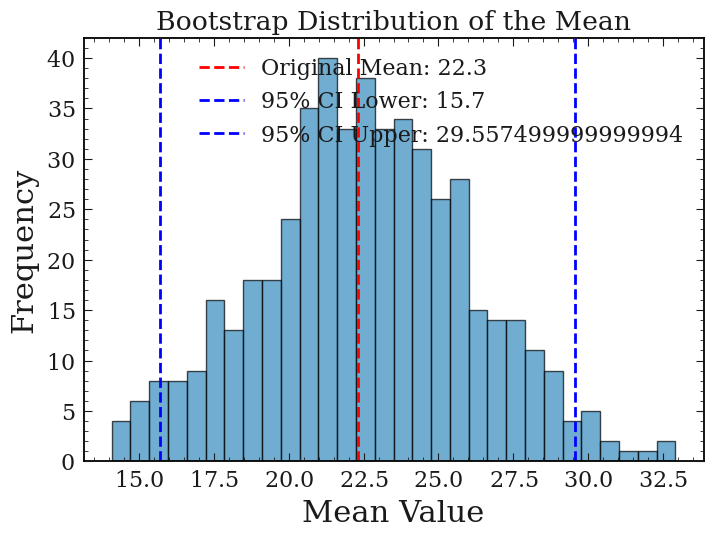

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# Original dataset
# data = np.array([2, 4, 6, 8, 10])
data = np.array([5, 9, 12, 15, 19, 25, 30, 33, 35, 40])  # Example data

# Function to compute the mean of a dataset
def compute_mean(data):
    return np.mean(data)

# Number of bootstrap samples
n_bootstrap = 500

# Array to store means of bootstrap samples
bootstrap_means = []

# Bootstrap resampling
for _ in range(n_bootstrap):
    # Generate a bootstrap sample by sampling with replacement
    bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
    
    # Compute the mean of the bootstrap sample
    bootstrap_means.append(compute_mean(bootstrap_sample))

# Convert bootstrap_means to a numpy array for easier analysis
bootstrap_means = np.array(bootstrap_means)

# Calculate the original mean
original_mean = compute_mean(data)

# Calculate the 95% confidence interval from the bootstrap means
lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

# Output results
print(f"Original Mean: {original_mean}")
print(f"Bootstrap 95% Confidence Interval: ({lower_bound}, {upper_bound})")

# Plot the distribution of bootstrap means
plt.hist(bootstrap_means, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(original_mean, color='red', linestyle='dashed', linewidth=2, label=f'Original Mean: {original_mean}')
plt.axvline(lower_bound, color='blue', linestyle='dashed', linewidth=2, label=f'95% CI Lower: {lower_bound}')
plt.axvline(upper_bound, color='blue', linestyle='dashed', linewidth=2, label=f'95% CI Upper: {upper_bound}')
plt.title("Bootstrap Distribution of the Mean")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [73]:
bootstrap_means.mean()

22.578200000000002

In [74]:
import math

In [75]:
math.sqrt(0.001*0.001 + 0.00003*0.00003)

0.001000449898795537

In [76]:
math.sqrt(0.007 *0.007  + 0.0013 *0.0013 )

0.007119691004531026

In [77]:
math.sqrt(0.008 *0.008   + 0.0089*0.0089 )

0.01196703806294607

In [78]:
math.sqrt(0.003 *0.003  + 0.0024 *0.0024 )

0.003841874542459709